In [267]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from itertools import product, combinations


import sys
import importlib


sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")


import current_measurements.src.src_current_measurement_simulations
importlib.reload(current_measurements.src.src_current_measurement_simulations);
from current_measurements.src.src_current_measurement_simulations import CurrentMeasurementSimulation

import current_measurements.src.src_current_measurement_simulations_particle_sector
importlib.reload(current_measurements.src.src_current_measurement_simulations_particle_sector);
from current_measurements.src.src_current_measurement_simulations_particle_sector import CurrentMeasurementSimulationParticleSector


from current_simulations.current_simulation import FockBasisState, convert_reduced_to_fock_state


In [277]:
num_levels = 5
num_qubits = 8
num_particles = 4

J = -6 * 2 * np.pi # MHz

U = -80 * 2 * np.pi # MHz
# U = -10000 * 2 * np.pi # MHz

times = np.linspace(0,0.1,101)
measurement_detunings = np.array([400, 400, -300, -300, 300, 300, -200, -200])*2*np.pi

# psi0 = qt.Qobj([1,0])
psi0 = -1


simulation_0_flux = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, abs(J), U, times,
                                                        [1,2], [3,4], measurement_detuning=measurement_detunings, psi0=psi0, T1=None, T2=None)

simulation_pi_flux = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, -abs(J), U, times,
                                                        [1,2], [3,4], measurement_detuning=measurement_detunings, psi0=psi0, T1=None, T2=None)


H_0_flux = simulation_0_flux.initial_Hamiltonian
H_0_flux_array = H_0_flux.full()

H_pi_flux = simulation_pi_flux.initial_Hamiltonian
H_pi_flux_array = H_pi_flux.full()

Number of basis states: 330
[(4, 0, 0, 0, 0, 0, 0, 0), (3, 1, 0, 0, 0, 0, 0, 0), (2, 2, 0, 0, 0, 0, 0, 0), (1, 3, 0, 0, 0, 0, 0, 0), (0, 4, 0, 0, 0, 0, 0, 0), (3, 0, 1, 0, 0, 0, 0, 0), (2, 1, 1, 0, 0, 0, 0, 0), (1, 2, 1, 0, 0, 0, 0, 0), (0, 3, 1, 0, 0, 0, 0, 0), (2, 0, 2, 0, 0, 0, 0, 0), (1, 1, 2, 0, 0, 0, 0, 0), (0, 2, 2, 0, 0, 0, 0, 0), (1, 0, 3, 0, 0, 0, 0, 0), (0, 1, 3, 0, 0, 0, 0, 0), (0, 0, 4, 0, 0, 0, 0, 0), (3, 0, 0, 1, 0, 0, 0, 0), (2, 1, 0, 1, 0, 0, 0, 0), (1, 2, 0, 1, 0, 0, 0, 0), (0, 3, 0, 1, 0, 0, 0, 0), (2, 0, 1, 1, 0, 0, 0, 0), (1, 1, 1, 1, 0, 0, 0, 0), (0, 2, 1, 1, 0, 0, 0, 0), (1, 0, 2, 1, 0, 0, 0, 0), (0, 1, 2, 1, 0, 0, 0, 0), (0, 0, 3, 1, 0, 0, 0, 0), (2, 0, 0, 2, 0, 0, 0, 0), (1, 1, 0, 2, 0, 0, 0, 0), (0, 2, 0, 2, 0, 0, 0, 0), (1, 0, 1, 2, 0, 0, 0, 0), (0, 1, 1, 2, 0, 0, 0, 0), (0, 0, 2, 2, 0, 0, 0, 0), (1, 0, 0, 3, 0, 0, 0, 0), (0, 1, 0, 3, 0, 0, 0, 0), (0, 0, 1, 3, 0, 0, 0, 0), (0, 0, 0, 4, 0, 0, 0, 0), (3, 0, 0, 0, 1, 0, 0, 0), (2, 1, 0, 0, 1, 0, 0, 0), (1, 2, 0,

In [278]:
eigenvalues_0_flux = simulation_0_flux.particle_number_to_eigenenergy[num_particles]
eigenstates_0_flux = simulation_0_flux.particle_number_to_eigenstate[num_particles]

eigenvalues_pi_flux = simulation_pi_flux.particle_number_to_eigenenergy[num_particles]
eigenstates_pi_flux = simulation_pi_flux.particle_number_to_eigenstate[num_particles]

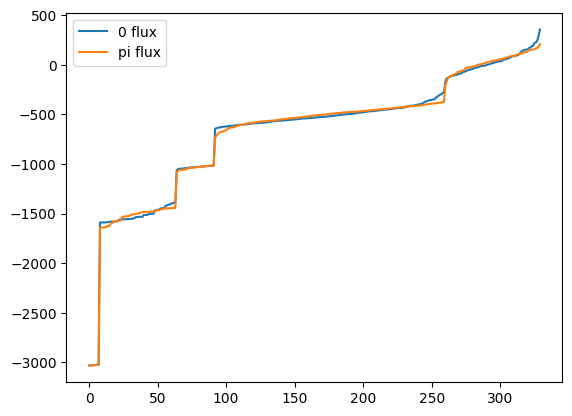

In [279]:
# for i in range(len(eigenvalues)):

plt.plot(eigenvalues_0_flux, label='0 flux')
plt.plot(eigenvalues_pi_flux, label='pi flux')
plt.legend()
plt.show()

In [284]:
# find smallest eigenvalue greater than -800 and its index in the original list
engery_cutoff = -250
candidates = [v for v in eigenvalues_0_flux if v > engery_cutoff]
if not candidates:
    print(f"No eigenvalue greater than {engery_cutoff} found.")
else:
    min_val_0_flux = min(candidates)
    idx_0_flux = eigenvalues_0_flux.index(min_val_0_flux)
    print("index:", idx_0_flux, "value:", min_val_0_flux/2/np.pi, "MHz")

candidates = [v for v in eigenvalues_pi_flux if v > engery_cutoff]
if not candidates:
    print(f"No eigenvalue greater than {engery_cutoff} found.")
else:
    min_val_pi_flux = min(candidates)
    idx_pi_flux = eigenvalues_pi_flux.index(min_val_pi_flux)
    print("index:", idx_pi_flux, "value:", min_val_pi_flux/2/np.pi, "MHz")

index: 260 value: -27.16415182870127 MHz
index: 260 value: -33.37567294004613 MHz


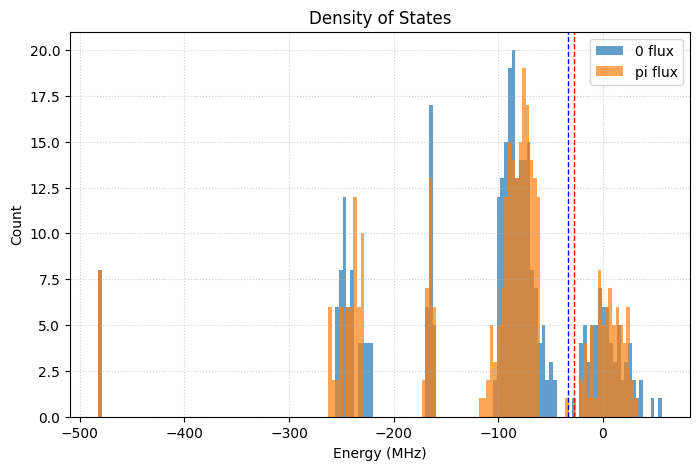

In [285]:
plt.figure(figsize=(8,5))
plt.hist(np.array(eigenvalues_0_flux)/(2*np.pi), bins=150, label='0 flux', alpha=0.7)
plt.hist(np.array(eigenvalues_pi_flux)/(2*np.pi), bins=150, label='pi flux', alpha=0.7)
plt.xlabel('Energy (MHz)')
plt.ylabel('Count')
plt.title('Density of States')
plt.grid(True, linestyle=':', alpha=0.6)

plt.axvline(min_val_0_flux/2/np.pi, color='r', linestyle='--', linewidth=1)
plt.axvline(min_val_pi_flux/2/np.pi, color='b', linestyle='--', linewidth=1)

plt.legend()

plt.show()

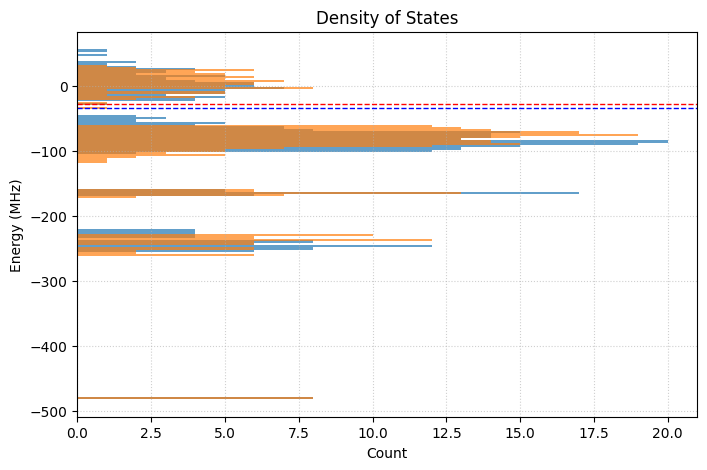

In [286]:
plt.figure(figsize=(8,5))
plt.hist(np.array(eigenvalues_0_flux)/(2*np.pi), bins=150, label='0 flux', alpha=0.7, orientation='horizontal')
plt.hist(np.array(eigenvalues_pi_flux)/(2*np.pi), bins=150, label='pi flux', alpha=0.7, orientation='horizontal')
plt.ylabel('Energy (MHz)')
plt.xlabel('Count')
plt.title('Density of States')
plt.grid(True, linestyle=':', alpha=0.6)

plt.axhline(min_val_0_flux/2/np.pi, color='r', linestyle='--', linewidth=1)
plt.axhline(min_val_pi_flux/2/np.pi, color='b', linestyle='--', linewidth=1)


plt.show()

In [287]:
lowest_eigenstate_0_flux = eigenstates_0_flux[idx_0_flux]
highest_eigenstate_0_flux = eigenstates_0_flux[-1]

lowest_eigenstate_pi_flux = eigenstates_pi_flux[idx_pi_flux]
highest_eigenstate_pi_flux = eigenstates_pi_flux[-1]


eigenstates_pi_flux = [lowest_eigenstate_pi_flux, highest_eigenstate_pi_flux]
eigenstates_0_flux = [lowest_eigenstate_0_flux, highest_eigenstate_0_flux]

In [288]:
basis = product(range(num_levels), repeat=num_qubits)

basis_4_particles = [state for state in basis if sum(state) == num_particles]

print(basis_4_particles)
print(len(basis_4_particles))


[(0, 0, 0, 0, 0, 0, 0, 4), (0, 0, 0, 0, 0, 0, 1, 3), (0, 0, 0, 0, 0, 0, 2, 2), (0, 0, 0, 0, 0, 0, 3, 1), (0, 0, 0, 0, 0, 0, 4, 0), (0, 0, 0, 0, 0, 1, 0, 3), (0, 0, 0, 0, 0, 1, 1, 2), (0, 0, 0, 0, 0, 1, 2, 1), (0, 0, 0, 0, 0, 1, 3, 0), (0, 0, 0, 0, 0, 2, 0, 2), (0, 0, 0, 0, 0, 2, 1, 1), (0, 0, 0, 0, 0, 2, 2, 0), (0, 0, 0, 0, 0, 3, 0, 1), (0, 0, 0, 0, 0, 3, 1, 0), (0, 0, 0, 0, 0, 4, 0, 0), (0, 0, 0, 0, 1, 0, 0, 3), (0, 0, 0, 0, 1, 0, 1, 2), (0, 0, 0, 0, 1, 0, 2, 1), (0, 0, 0, 0, 1, 0, 3, 0), (0, 0, 0, 0, 1, 1, 0, 2), (0, 0, 0, 0, 1, 1, 1, 1), (0, 0, 0, 0, 1, 1, 2, 0), (0, 0, 0, 0, 1, 2, 0, 1), (0, 0, 0, 0, 1, 2, 1, 0), (0, 0, 0, 0, 1, 3, 0, 0), (0, 0, 0, 0, 2, 0, 0, 2), (0, 0, 0, 0, 2, 0, 1, 1), (0, 0, 0, 0, 2, 0, 2, 0), (0, 0, 0, 0, 2, 1, 0, 1), (0, 0, 0, 0, 2, 1, 1, 0), (0, 0, 0, 0, 2, 2, 0, 0), (0, 0, 0, 0, 3, 0, 0, 1), (0, 0, 0, 0, 3, 0, 1, 0), (0, 0, 0, 0, 3, 1, 0, 0), (0, 0, 0, 0, 4, 0, 0, 0), (0, 0, 0, 1, 0, 0, 0, 3), (0, 0, 0, 1, 0, 0, 1, 2), (0, 0, 0, 1, 0, 0, 2, 1), (0, 0, 0, 1

In [289]:
# build projector onto states in basis_4_particles with at most one particle per site
single_occupancy_inds = [i for i, state in enumerate(basis_4_particles) if all(x <= 1 for x in state)]

# sanity
print("number of basis states with at most one particle per site:", len(single_occupancy_inds))  # should be comb(8,4)=70

# this number should be equal to comb(8,4)
from math import comb
print("comb(8,4) =", comb(8, 4))

mask = np.zeros(len(basis_4_particles), dtype=float)
mask[single_occupancy_inds] = 1.0

# create Qobj projector in the same dims as the eigenstate/kets (operator dims = [N],[N])
N = len(basis_4_particles)
proj_op = qt.Qobj(np.diag(mask), dims=[eigenstates_0_flux[0].dims[0], eigenstates_0_flux[0].dims[0]])

# example: probability that lowest_eigenstate lies in that subspace
prob_lowest_0_flux = lowest_eigenstate_0_flux.dag() * proj_op * lowest_eigenstate_0_flux
prob_lowest_pi_flux = lowest_eigenstate_pi_flux.dag() * proj_op * lowest_eigenstate_pi_flux
print("projection probability (lowest_eigenstate 0 flux):", prob_lowest_0_flux)
print("projection probability (lowest_eigenstate pi flux):", prob_lowest_pi_flux)

# example: probability that highest_eigenstate lies in that subspace
prob_highest_0_flux = highest_eigenstate_0_flux.dag() * proj_op * highest_eigenstate_0_flux
prob_highest_pi_flux = highest_eigenstate_pi_flux.dag() * proj_op * highest_eigenstate_pi_flux
print("projection probability (highest_eigenstate 0 flux):", prob_highest_0_flux)
print("projection probability (highest_eigenstate pi flux):", prob_highest_pi_flux)
# proj_op can now be used to project any ket in this 4-particle sector: projected_ket = proj_op * some_ket

number of basis states with at most one particle per site: 70
comb(8,4) = 70
projection probability (lowest_eigenstate 0 flux): (0.9560592269097608+0j)
projection probability (lowest_eigenstate pi flux): (0.8305565112374824+0j)
projection probability (highest_eigenstate 0 flux): (0.9145310319228473+0j)
projection probability (highest_eigenstate pi flux): (0.9715148905276111+0j)


In [290]:
lowest_data_0_flux = lowest_eigenstate_0_flux.full().flatten()
highest_data_0_flux = highest_eigenstate_0_flux.full().flatten()

lowest_data = lowest_data_0_flux
highest_data = highest_data_0_flux

for lowest_eigenstate, highest_eigenstate in zip(eigenstates_0_flux, eigenstates_pi_flux):
    lowest_data = lowest_eigenstate.full().flatten()
    highest_data = highest_eigenstate.full().flatten()


    lowest_sum_subspace = 0
    lowest_sum_outside = 0
    lowest_max_amplitude = 0
    lowest_max_index = -1

    highest_sum_subspace = 0
    highest_sum_outside = 0
    highest_max_amplitude = 0
    highest_max_index = -1
    for i in range(len(basis_4_particles)):
        # print(basis_4_particles[i], " lowest:", (abs(lowest_data[i])**2), " highest:", (abs(highest_data[i])**2))
        
        if abs(lowest_data[i])**2 > lowest_max_amplitude:
            lowest_max_amplitude = abs(lowest_data[i])**2
            lowest_max_index = i

        if abs(highest_data[i])**2 > highest_max_amplitude:
            highest_max_amplitude = abs(highest_data[i])**2
            highest_max_index = i

        if any(np.array(basis_4_particles[i]) > 1):
            lowest_sum_outside += abs(lowest_data[i])**2
            highest_sum_outside += abs(highest_data[i])**2
        else:
            lowest_sum_subspace += abs(lowest_data[i])**2
            highest_sum_subspace += abs(highest_data[i])**2

    print("lowest_eigenstate sum in subspace:", lowest_sum_subspace, " outside subspace:", lowest_sum_outside)
    print("highest_eigenstate sum in subspace:", highest_sum_subspace, " outside subspace:", highest_sum_outside)

    print(f'lowest_eigenstate max amplitude {lowest_max_amplitude} at index {lowest_max_index}, state {basis_4_particles[lowest_max_index]}')
    print(f'highest_eigenstate max amplitude {highest_max_amplitude} at index {highest_max_index}, state {basis_4_particles[highest_max_index]}')
    print()
    print()

lowest_eigenstate sum in subspace: 0.9560592269097608  outside subspace: 0.043940773090239776
highest_eigenstate sum in subspace: 0.8305565112374824  outside subspace: 0.16944348876251697
lowest_eigenstate max amplitude 0.10174805592283322 at index 165, state (0, 1, 1, 0, 0, 1, 1, 0)
highest_eigenstate max amplitude 0.04864744883107501 at index 236, state (1, 0, 0, 1, 1, 0, 0, 1)


lowest_eigenstate sum in subspace: 0.9145310319228473  outside subspace: 0.08546896807715237
highest_eigenstate sum in subspace: 0.9715148905276111  outside subspace: 0.028485109472388175
lowest_eigenstate max amplitude 0.029461093556618172 at index 165, state (0, 1, 1, 0, 0, 1, 1, 0)
highest_eigenstate max amplitude 0.07101204000079045 at index 236, state (1, 0, 0, 1, 1, 0, 0, 1)




In [291]:
# build flip operator on the 4-particle sector: flip 0<->1 for states with only 0s and 1s;
# leave other basis states unchanged (identity action)
N = len(basis_4_particles)
state_to_index = {state: i for i, state in enumerate(basis_4_particles)}

mat = np.zeros((N, N), dtype=complex)
for i, state in enumerate(basis_4_particles):
    if mask[i] == 1.0:  # single-occupancy (only 0/1 entries)
        flipped = tuple(1 - x for x in state)
        j = state_to_index.get(flipped)
        if j is None:
            raise RuntimeError(f"Flipped state {flipped} not found in basis.")
        mat[j, i] = 1.0
    else:
        mat[i, i] = 1.0  # leave outside states unchanged

flip_op = qt.Qobj(mat, dims=[eigenstates_0_flux[0].dims[0], eigenstates_0_flux[0].dims[0]])

# sanity checks
I = qt.qeye(N)
unitary_error = (flip_op.dag() * flip_op - I).full()
print("max |U^†U - I| =", np.max(np.abs(unitary_error)))
# example: check mapping of one single-occupancy basis ket
example_idx = single_occupancy_inds[0]
print("example mapping:", basis_4_particles[example_idx], "->", basis_4_particles[state_to_index[tuple(1 - np.array(basis_4_particles[example_idx]))]])

max |U^†U - I| = 0.0
example mapping: (0, 0, 0, 0, 1, 1, 1, 1) -> (1, 1, 1, 1, 0, 0, 0, 0)


In [292]:
# find diagonal entries not equal to 1 (with numerical tolerance)
diag = np.diag(flip_op.full())
bad_inds = np.where(~np.isclose(diag, 1.0, atol=1e-12))[0]

print("indices with flip_op[i,i] != 1:", bad_inds.tolist())
print(f'number of indices where a state is flipped: {len(bad_inds.tolist())}')
print(f'this should be equal to comb(8,4) = {comb(8,4)}')
# print("diagonal values at those indices:", diag[bad_inds])

indices with flip_op[i,i] != 1: [20, 40, 46, 48, 49, 75, 81, 83, 84, 91, 93, 94, 96, 97, 98, 131, 137, 139, 140, 147, 149, 150, 152, 153, 154, 162, 164, 165, 167, 168, 169, 171, 172, 173, 174, 215, 221, 223, 224, 231, 233, 234, 236, 237, 238, 246, 248, 249, 251, 252, 253, 255, 256, 257, 258, 267, 269, 270, 272, 273, 274, 276, 277, 278, 279, 281, 282, 283, 284, 285]
number of indices where a state is flipped: 70
this should be equal to comb(8,4) = 70


In [293]:
highest_reduced = highest_eigenstate[single_occupancy_inds].flatten()
lowest_reduced = lowest_eigenstate[single_occupancy_inds].flatten()

print(highest_reduced @ highest_reduced)

(0.9715148905276115+0j)


(0, 0, 0, 0, 1, 1, 1, 1) 0.003 0.003
(0, 0, 0, 1, 0, 1, 1, 1) 0.063 0.063
(0, 0, 0, 1, 1, 0, 1, 1) -0.041 -0.04
(0, 0, 0, 1, 1, 1, 0, 1) -0.082 -0.098
(0, 0, 0, 1, 1, 1, 1, 0) 0.086 0.106
(0, 0, 1, 0, 0, 1, 1, 1) -0.04 -0.041
(0, 0, 1, 0, 1, 0, 1, 1) -0.031 -0.031
(0, 0, 1, 0, 1, 1, 0, 1) 0.042 0.043
(0, 0, 1, 0, 1, 1, 1, 0) 0.01 0.015
(0, 0, 1, 1, 0, 0, 1, 1) 0.111 0.111
(0, 0, 1, 1, 0, 1, 0, 1) 0.092 0.112
(0, 0, 1, 1, 0, 1, 1, 0) -0.159 -0.185
(0, 0, 1, 1, 1, 0, 0, 1) -0.133 -0.168
(0, 0, 1, 1, 1, 0, 1, 0) 0.068 0.072
(0, 0, 1, 1, 1, 1, 0, 0) 0.091 0.138
(0, 1, 0, 0, 0, 1, 1, 1) -0.098 -0.082
(0, 1, 0, 0, 1, 0, 1, 1) 0.043 0.042
(0, 1, 0, 0, 1, 1, 0, 1) 0.133 0.133
(0, 1, 0, 0, 1, 1, 1, 0) -0.128 -0.142
(0, 1, 0, 1, 0, 0, 1, 1) 0.112 0.092
(0, 1, 0, 1, 0, 1, 0, 1) 0.043 0.043
(0, 1, 0, 1, 0, 1, 1, 0) -0.112 -0.099
(0, 1, 0, 1, 1, 0, 0, 1) -0.174 -0.165
(0, 1, 0, 1, 1, 0, 1, 0) 0.14 0.137
(0, 1, 0, 1, 1, 1, 0, 0) 0.068 0.072
(0, 1, 1, 0, 0, 0, 1, 1) -0.168 -0.133
(0, 1, 1, 0, 0, 1, 0

c:\Users\mattm\OneDrive\Desktop\Research\Software\venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


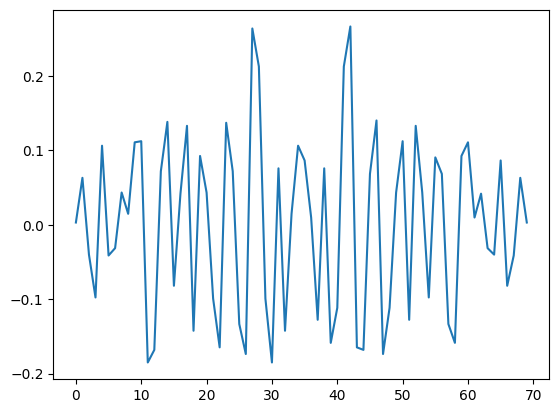

In [294]:
flip_op_reduced = np.diag(np.ones(len(single_occupancy_inds)))[:,::-1]

highest_flipped_reduced = np.zeros(len(single_occupancy_inds), dtype=complex)

for i in range(len(basis_4_particles)):
    if mask[i] == 1.0:
        j = state_to_index[tuple(1 - np.array(basis_4_particles[i]))]
        if mask[j] == 1.0:
            idx_i = single_occupancy_inds.index(i)
            idx_j = single_occupancy_inds.index(j)
            highest_flipped_reduced[idx_j] = highest_reduced[idx_i]


for i in range(len(single_occupancy_inds)):
    print(basis_4_particles[single_occupancy_inds[i]], round(highest_flipped_reduced[i].real, 3), round(highest_reduced[i].real, 3))

plt.plot(highest_reduced)


In [295]:
highest_flipped = flip_op * highest_eigenstate
lowest_flipped = flip_op * lowest_eigenstate

overlap = highest_flipped.dag() * highest_eigenstate
print("overlap between flipped highest_eigenstate and highest_eigenstate:", overlap)

overlap = lowest_flipped.dag() * highest_eigenstate
print("overlap between flipped lowest_eigenstate and highest_eigenstate:", overlap)

overlap = highest_flipped.dag() * lowest_eigenstate
print("overlap between flipped highest_eigenstate and lowest_eigenstate:", overlap)

overlap = lowest_flipped.dag() * lowest_eigenstate
print("overlap between flipped lowest_eigenstate and lowest_eigenstate:", overlap)

overlap between flipped highest_eigenstate and highest_eigenstate: (0.9908500372597298+0j)
overlap between flipped lowest_eigenstate and highest_eigenstate: (0.07886296486645461+0j)
overlap between flipped highest_eigenstate and lowest_eigenstate: (0.07886296486645458+0j)
overlap between flipped lowest_eigenstate and lowest_eigenstate: (0.9769003410475315+0j)


In [ ]:

# highest_flipped_pi_flux = highest_flipped
# lowest_flipped_pi_flux = lowest_flipped

# highest_flipped_0_flux = highest_flipped
# lowest_flipped_0_flux = lowest_flipped

In [296]:
# compute overlaps between all combinations of the six states (0/pi flux, lowest/highest, flipped/not)
expected_names = [
    'lowest_eigenstate_pi_flux', 'highest_eigenstate_pi_flux', 'lowest_flipped_pi_flux', 'highest_flipped_pi_flux',
    'lowest_eigenstate_0_flux',  'highest_eigenstate_0_flux',  'lowest_flipped_0_flux', 'highest_flipped_0_flux'
]

# collect available states
labels = []
states = []
for name in expected_names:
    if name in globals():
        labels.append(name)
        states.append(globals()[name])
    else:
        print(f"Warning: {name} not found -> skipping")

if len(states) < 2:
    print("Need at least two states to compute overlaps.")
else:
    n = len(states)
    overlaps = np.zeros((n, n), dtype=complex)
    for i in range(n):
        for j in range(n):
            # compute scalar overlap <i|j>
            val_qobj = states[i].dag() * states[j]
            # extract complex scalar
            val = complex(val_qobj)
            overlaps[i, j] = val

    abs_overlaps = np.abs(overlaps)

    # print header
    print("Labels (in order):")
    for k, lab in enumerate(labels):
        print(f"  [{k}] {lab}")
    print()

    # print complex overlap matrix
    print("Overlap matrix <i|j> (complex):")
    for i in range(n):
        row = []
        for j in range(n):
            v = overlaps[i, j]
            row.append(f"{v.real:+.3f}")
        print(f"[{i}] " + "  ".join(row))
    print()

    # print absolute overlaps
    print("Absolute overlaps |<i|j>|:")
    for i in range(n):
        row = ["{:.6f}".format(abs_overlaps[i, j]) for j in range(n)]
        print(f"[{i}] " + "  ".join(row))
    print()

    # diagnostics
    # max off-diagonal absolute overlap and its indices
    off_diag_mask = ~np.eye(n, dtype=bool)
    max_offdiag = abs_overlaps[off_diag_mask].max() if n > 1 else 0.0
    if max_offdiag > 1e-6:
        idx = np.unravel_index(np.argmax(abs_overlaps * off_diag_mask), (n, n))
        print(f"Max off-diagonal |<i|j>| = {max_offdiag:.6e} at indices {idx} -> ({labels[idx[0]]}, {labels[idx[1]]})")
    else:
        print("All off-diagonal overlaps are <= 1e-6 (effectively orthogonal).")

    # check Hermiticity: overlaps should satisfy overlaps = overlaps.conj().T
    herm_err = np.max(np.abs(overlaps - overlaps.conj().T))
    print(f"Hermiticity check max|O - O^†| = {herm_err:.3e}")

Labels (in order):
  [0] lowest_eigenstate_pi_flux
  [1] highest_eigenstate_pi_flux
  [2] lowest_flipped_pi_flux
  [3] highest_flipped_pi_flux
  [4] lowest_eigenstate_0_flux
  [5] highest_eigenstate_0_flux
  [6] lowest_flipped_0_flux
  [7] highest_flipped_0_flux

Overlap matrix <i|j> (complex):
[0] +1.000  -0.000  +0.896  -0.002  +0.147  -0.122  -0.126  +0.117
[1] -0.000  +1.000  -0.001  -0.977  -0.328  +0.076  +0.349  -0.099
[2] +0.896  -0.001  +1.000  -0.000  +0.174  -0.095  -0.132  +0.107
[3] -0.002  -0.977  -0.000  +1.000  +0.332  -0.111  -0.352  +0.131
[4] +0.147  -0.328  +0.174  +0.332  +1.000  +0.000  -0.968  +0.000
[5] -0.122  +0.076  -0.095  -0.111  +0.000  +1.000  +0.001  -0.949
[6] -0.126  +0.349  -0.132  -0.352  -0.968  +0.001  +1.000  -0.000
[7] +0.117  -0.099  +0.107  +0.131  +0.000  -0.949  -0.000  +1.000

Absolute overlaps |<i|j>|:
[0] 1.000000  0.000000  0.895543  0.001745  0.146576  0.121774  0.126050  0.116526
[1] 0.000000  1.000000  0.000978  0.977473  0.327916  0.0

In [297]:
### construct current operators manually

current_operators = []
for i in range(num_qubits):
    current_operator = np.zeros((len(basis_4_particles), len(basis_4_particles)), dtype=complex)
    current_operators.append(current_operator)
    for m in range(len(basis_4_particles)):
        # print(state_m)
        for n in range(len(basis_4_particles)):
            # print('\t', state_n)
            # compute matrix element <m|J_i|n>
            # J_i = -i * J * (a_i^† a_{i+1} - a_{i+1}^† a_i)
            state_m = basis_4_particles[m]
            state_n = basis_4_particles[n]
            
            # check if state_n can be transformed to state_m by hopping a particle from i+1 to i
            if i < num_qubits - 1 and state_n[i + 1] == state_m[i] + 1:
                # particle hops from i+1 to i
                new_state = list(state_n)
                new_state[i] += 1
                new_state[i + 1] -= 1
                if tuple(new_state) == state_m:
                    element = -np.sqrt(state_n[i + 1])*np.sqrt(state_m[i])*1j * J
                    current_operators[i][m, n] = element
            
            # check if state_n can be transformed to state_m by hopping a particle from i to i+1
            if i < num_qubits - 1 and state_n[i] == state_m[i + 1] + 1:
                # particle hops from i to i+1
                new_state = list(state_n)
                new_state[i+1] += 1
                new_state[i] -= 1
                if tuple(new_state) == state_m:
                    element = -np.sqrt(state_n[i])*np.sqrt(state_m[i + 1])*1j * J
                    current_operators[i][m, n] = element

    current_operators[i] = qt.Qobj(current_operators[i], dims=[eigenstates_0_flux[0].dims[0], eigenstates_0_flux[0].dims[0]])

# assume 12-34 current correlators for all

current_correlator = current_operators[1] * current_operators[3]

In [299]:
### construct number operators manually

number_operators = []

for i in range(num_qubits):
    number_operator = np.zeros((len(basis_4_particles), len(basis_4_particles)), dtype=complex)
    number_operators.append(number_operator)
    for m in range(len(basis_4_particles)):
        state_m = basis_4_particles[m]
        number_operator[m, m] = state_m[i]

    number_operators[i] = qt.Qobj(number_operators[i], dims=[eigenstates_0_flux[0].dims[0], eigenstates_0_flux[0].dims[0]])

In [300]:
### calculate qubit particle number and current correlation for both states

def expectations_for_state(psi):
    # per-qubit particle numbers and currents
    n_expect = np.array([ (psi.dag() * n_op * psi).real for n_op in number_operators])
    n_expect = np.round(n_expect, decimals=2)  # round to avoid tiny numerical errors
    j_expect = np.array([ (psi.dag() * j_op * psi).real for j_op in current_operators])
    j_expect = np.round(j_expect, decimals=2)  # round to avoid tiny numerical errors
    # two-point current correlator matrix and connected correlator
    Nq = len(current_operators)
    jj_corr = np.zeros((Nq, Nq))
    for i in range(Nq):
        for j in range(Nq):
            jj_corr[i, j] = (psi.dag() * current_operators[i] * current_operators[j] * psi).real
    jj_conn = jj_corr - np.outer(j_expect, j_expect)
    jj_corr = np.round(jj_corr, decimals=2)  # round to avoid tiny numerical errors
    jj_conn = np.round(jj_conn, decimals=2)  # round to avoid tiny numerical errors
    return dict(n_expect=n_expect, j_expect=j_expect, jj_corr=jj_corr, jj_conn=jj_conn)

# compute for both states
res_low = expectations_for_state(lowest_eigenstate)
res_high = expectations_for_state(highest_eigenstate)

# print summaries
print("Lowest eigenstate:")
print("  total particles (sum of per-qubit expectations):", np.sum(res_low['n_expect']))
print("  per-qubit particle numbers:", res_low['n_expect'])
print("  per-link current expectations:", res_low['j_expect'])
print("  connected current correlator between link 1 and 3:",
      res_low['jj_conn'][1, 3])

print("\nHighest eigenstate:")
print("  total particles (sum of per-qubit expectations):", np.sum(res_high['n_expect']))
print("  per-qubit particle numbers:", res_high['n_expect'])
print("  per-link current expectations:", res_high['j_expect'])
print("  connected current correlator between link 1 and 3:",
      res_high['jj_conn'][1, 3])

# check flipped state too
print("\nFlipped lowest eigenstate:")
res_flipped = expectations_for_state(flipped_state)
print("  total particles (sum of per-qubit expectations):", np.sum(res_flipped['n_expect']))
print("  per-qubit particle numbers:", res_flipped['n_expect'])
print("  per-link current expectations:", res_flipped['j_expect'])
print("  connected current correlator between link 1 and 3:",
      res_flipped['jj_conn'][1, 3])

# optionally expose full correlator matrices to variables for later use
qubit_particle_numbers_low = res_low['n_expect']
qubit_particle_numbers_high = res_high['n_expect']
current_jj_corr_low = res_low['jj_corr']
current_jj_corr_high = res_high['jj_corr']
current_jj_conn_low = res_low['jj_conn']
current_jj_conn_high = res_high['jj_conn']

qubit_particle_numbers_flipped = res_flipped['n_expect']
current_jj_corr_flipped = res_flipped['jj_corr']
current_jj_conn_flipped = res_flipped['jj_conn']

Lowest eigenstate:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.42 0.5  0.54 0.54 0.54 0.54 0.5  0.42]
  per-link current expectations: [0. 0. 0. 0. 0. 0. 0. 0.]
  connected current correlator between link 1 and 3: -5.01

Highest eigenstate:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.48 0.47 0.52 0.53 0.53 0.52 0.47 0.48]
  per-link current expectations: [0. 0. 0. 0. 0. 0. 0. 0.]
  connected current correlator between link 1 and 3: -1.73

Flipped lowest eigenstate:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.45 0.5  0.53 0.52 0.52 0.53 0.5  0.45]
  per-link current expectations: [0. 0. 0. 0. 0. 0. 0. 0.]
  connected current correlator between link 1 and 3: -1.2


In [301]:
all_states = [lowest_eigenstate_pi_flux, highest_eigenstate_pi_flux, lowest_flipped_pi_flux, highest_flipped_pi_flux,
              lowest_eigenstate_0_flux, highest_eigenstate_0_flux, lowest_flipped_0_flux, highest_flipped_0_flux]

all_states_labels = ['lowest_eigenstate_pi_flux', 'highest_eigenstate_pi_flux', 'lowest_flipped_pi_flux', 'highest_flipped_pi_flux',
                     'lowest_eigenstate_0_flux', 'highest_eigenstate_0_flux', 'lowest_flipped_0_flux', 'highest_flipped_0_flux']
for i in range(len(all_states)):
    state = all_states[i]
    label = all_states_labels[i]
    res = expectations_for_state(state)
    print(f"\n{label}:")
    print("  total particles (sum of per-qubit expectations):", np.sum(res['n_expect']))
    print("  per-qubit particle numbers:", res['n_expect'])
    print("  per-link current expectations:", res['j_expect'])
    print("  connected current correlator between link 1 and 3:",
          res['jj_conn'][1, 3])


lowest_eigenstate_pi_flux:
  total particles (sum of per-qubit expectations): 3.9799999999999995
  per-qubit particle numbers: [0.59 0.48 0.45 0.47 0.47 0.45 0.48 0.59]
  per-link current expectations: [0. 0. 0. 0. 0. 0. 0. 0.]
  connected current correlator between link 1 and 3: -2.79

highest_eigenstate_pi_flux:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.48 0.47 0.52 0.53 0.53 0.52 0.47 0.48]
  per-link current expectations: [0. 0. 0. 0. 0. 0. 0. 0.]
  connected current correlator between link 1 and 3: -1.73

lowest_flipped_pi_flux:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
  per-link current expectations: [0. 0. 0. 0. 0. 0. 0. 0.]
  connected current correlator between link 1 and 3: -0.0

highest_flipped_pi_flux:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
  per-link current expectations:

In [200]:
### try measuring current with fock state representation

# calculate correlations
# current operator is -J_ij(a_i^dagger a_j - a_j^dagger a_i)*J_kl(a_k^dagger a_l - a_l^dagger a_k)


# print('calculating current correlations with initial state:')
# print(psi0)

def get_current_expectations(psi0_fock):
    # define the leg current operator as j_j,m = −iJ(exp(iχ(−1)^m b†_j,m b_j+1,m − H.c.)
    # let's define the phase through each plaquette as chi. Let's put all the phase in the J_parallel coupling, so rung coupling is the same but with chi = 0
    # for example, for a right side up plaquette, j_j,1 = −iJ(exp(-iχ b†_j,1 b_j+1,1 − H.c.)
    # for example, for a upside down plaquette, j_j,2 = −iJ(exp(iχ b†_j,2 b_j+1,2 − H.c.)
    # phase information stored in coupling in Hamiltonian matrix element

    current_expectations = []
    for i in range(num_qubits - 1):
            
        q_1 = i + 1
        q_2 = i + 2


        # phase information stored in coupling in Hamiltonian matrix element
        coupling = H_array[q_1 - 1, q_2 - 1]

        value = 0
        # a_i^dagger a_j term
        new_state = psi0_fock.apply_raising_operator(q_1-1, num_levels).apply_lowering_operator(q_2-1)
        value += psi0_fock.inner_product(new_state) * -1j * coupling
        # a_j^dagger a_i term
        new_state = psi0_fock.apply_lowering_operator(q_1-1).apply_raising_operator(q_2-1, num_levels)
        value -= psi0_fock.inner_product(new_state) * -1j * np.conjugate(coupling)

        # for rung currents starting at top rung, (odd qubits) multiply by -1
        if abs(q_1 - q_2) == 1 and q_1 % 2 == 1:
            value *= -1

        current_expectations.append(value.real/J)
        
    return current_expectations

def get_current_correlation(psi0_fock, q_11, q_12, q_21, q_22):



    # define the leg current operator as j_j,m = −iJ(exp(iχ(−1)^m b†_j,m b_j+1,m − H.c.)
    # let's define the phase through each plaquette as chi. Let's put all the phase in the J_parallel coupling, so rung coupling is the same but with chi = 0
    # for example, for a right side up plaquette, j_j,1 = −iJ(exp(-iχ b†_j,1 b_j+1,1 − H.c.)
    # for example, for a upside down plaquette, j_j,2 = −iJ(exp(iχ b†_j,2 b_j+1,2 − H.c.)
    # phase information stored in coupling in Hamiltonian matrix element




    if abs(q_11 - q_12) == 1:
        coupling_1 = J
    elif abs(q_11 - q_12) == 2:
        coupling_1 = J_parallel
    else:
        coupling_1 = 0

    if abs(q_11 - q_12) == 1:
        coupling_1 = J
    elif abs(q_11 - q_12) == 2:
        coupling_1 = J_parallel
    else:
        coupling_1 = 0

    if abs(q_21 - q_22) == 1:
        coupling_2 = J
    elif abs(q_21 - q_22) == 2:
        coupling_2 = J_parallel
    else:
        coupling_2 = 0

    value = 0
    # a_i^dagger a_j a_k^dagger a_l
    new_state = psi0_fock.apply_raising_operator(q_11-1, num_levels).apply_lowering_operator(q_12-1).apply_raising_operator(q_21-1, num_levels).apply_lowering_operator(q_22-1)
    value -= psi0_fock.inner_product(new_state) * coupling_1 * coupling_2

    # a_i^dagger a_j a_l^dagger a_k
    new_state = psi0_fock.apply_raising_operator(q_11-1, num_levels).apply_lowering_operator(q_12-1).apply_raising_operator(q_22-1, num_levels).apply_lowering_operator(q_21-1)
    value += psi0_fock.inner_product(new_state) * coupling_1 * np.conjugate(coupling_2)

    # a_j^dagger a_i a_k^dagger a_l
    new_state = psi0_fock.apply_raising_operator(q_12-1, num_levels).apply_lowering_operator(q_11-1).apply_raising_operator(q_21-1, num_levels).apply_lowering_operator(q_22-1)
    value += psi0_fock.inner_product(new_state) * np.conjugate(coupling_1) * coupling_2

    # a_j^dagger a_i a_l^dagger a_k
    new_state = psi0_fock.apply_raising_operator(q_12-1, num_levels).apply_lowering_operator(q_11-1).apply_raising_operator(q_22-1, num_levels).apply_lowering_operator(q_21-1)
    value -= psi0_fock.inner_product(new_state) * np.conjugate(coupling_1) * np.conjugate(coupling_2)

    # for rung currents starting at top rung, (odd qubits) multiply by -1
    if abs(q_11 - q_12) == 1 and q_11 % 2 == 1:
        value *= -1
    if abs(q_21 - q_22) == 1 and q_21 % 2 == 1:
        value *= -1

    return value.real/J/J

def get_number_expectations(psi0_fock):

    number_expectations = []
    for i in range(num_qubits):
        q = i + 1
        # n_q = a_q^dagger a_q
        new_state = psi0_fock.apply_lowering_operator(q-1).apply_raising_operator(q-1, num_levels)
        value = psi0_fock.inner_product(new_state)
        number_expectations.append(value.real)
    return number_expectations

def expectations_for_state_fock(psi0):
        
    all_qubits = list(range(1, num_qubits+1))
    all_qubit_pairs = list(combinations(all_qubits, 2))

    psi0_fock = convert_reduced_to_fock_state(basis_4_particles, psi0)
    

    current_correlations = get_current_correlation(psi0_fock, 1,2,3,4)

    number_expectations = get_number_expectations(psi0_fock)

    current_expectations = get_current_expectations(psi0_fock)

    current_correlations_connected = current_correlations - current_expectations[1]*current_expectations[3]
    
    return dict(n_expect=number_expectations, j_expect=current_expectations, jj_corr=current_correlations, jj_conn=current_correlations_connected)



In [221]:
all_states = [lowest_eigenstate_pi_flux, highest_eigenstate_pi_flux, lowest_flipped_pi_flux, highest_flipped_pi_flux,
              lowest_eigenstate_0_flux, highest_eigenstate_0_flux, lowest_flipped_0_flux, highest_flipped_0_flux]

all_states_labels = ['lowest_eigenstate_pi_flux', 'highest_eigenstate_pi_flux', 'lowest_flipped_pi_flux', 'highest_flipped_pi_flux',
                     'lowest_eigenstate_0_flux', 'highest_eigenstate_0_flux', 'lowest_flipped_0_flux', 'highest_flipped_0_flux']
for i in range(len(all_states)):
    state = all_states[i]
    label = all_states_labels[i]
    res = expectations_for_state_fock(state)
    print(f"\n{label}:")
    print("  total particles (sum of per-qubit expectations):", np.sum(res['n_expect']))
    print("  per-qubit particle numbers:", res['n_expect'])
    print("  per-link current expectations:", res['j_expect'])
    print("  connected current correlator between link 1 and 3:",
          res['jj_conn'])


lowest_eigenstate_pi_flux:
  total particles (sum of per-qubit expectations): 4.000000000000001
  per-qubit particle numbers: [0.500759288101849, 0.4999340514856273, 0.49961790442390863, 0.4996887559887401, 0.4996887559887302, 0.49961790442387793, 0.4999340514855941, 0.5007592881016735]
  per-link current expectations: [0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 0.0]
  connected current correlator between link 1 and 3: 0.06788402302614946

highest_eigenstate_pi_flux:
  total particles (sum of per-qubit expectations): 4.000000000000002
  per-qubit particle numbers: [0.49985181524557687, 0.4998268256777887, 0.5001727404073145, 0.5001486186691388, 0.5001486186692965, 0.5001727404069939, 0.49982682567830555, 0.4998518152455864]
  per-link current expectations: [0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 0.0]
  connected current correlator between link 1 and 3: 0.3184194326282677

lowest_flipped_pi_flux:
  total particles (sum of per-qubit expectations): 4.0
  per-qubit particle numbers: [0.49923885770542265,

In [266]:
### check if highest pi flux eigenstate is an eigenstate of H(phi0=0)
psi = highest_eigenstate_pi_flux

# energy expectation from H
E_expect = complex(psi.dag() * H_0_flux * psi).real
print("Energy expectation (MHz):", E_expect / 2 / np.pi)

# reported eigenvalues for this sector
print("Listed highest eigenvalue (MHz):", eigenvalues_0_flux[-1] / 2 / np.pi)

# find closest eigenvalue and its index
e_arr = np.array(eigenvalues_0_flux, dtype=float)
closest_idx = int(np.argmin(np.abs(e_arr - E_expect)))
print("Closest eigenvalue index:", closest_idx, "value (MHz):", e_arr[closest_idx] / 2 / np.pi,
    "difference (MHz):", (e_arr[closest_idx] - E_expect) / 2 / np.pi)

# residual norms to test eigenstate property
res_closest = (H * psi - e_arr[closest_idx] * psi).norm()
res_expect = (H * psi - E_expect * psi).norm()
print("Residual norm (using closest eigenvalue):", res_closest)
print("Residual norm (using expectation value):", res_expect)

Energy expectation (MHz): -11.441123802964126
Listed highest eigenvalue (MHz): 47.23486522541484
Closest eigenvalue index: 278 value (MHz): -11.466037870448952 difference (MHz): -0.024914067484826517
Residual norm (using closest eigenvalue): 194.46034192070806
Residual norm (using expectation value): 194.46027891381863
